In [1]:
import os
import glob
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


class LibrosaPairedAudioDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, sample_rate=16000, duration_sec=2.0, audioformat='*.wav'):
        self.noisy_dir = noisy_dir
        self.clean_dir = clean_dir
        self.target_sr = sample_rate
        self.target_len = int(sample_rate * duration_sec)

        self.noisy_files = sorted(glob.glob(os.path.join(self.noisy_dir, audioformat)))
        
        if len(self.noisy_files) == 0:
            self.filenames = sorted([f for f in os.listdir(noisy_dir) if f.endswith('.wav')])
            if len(self.filenames) == 0:
                assert False, f"No .wav files found in {noisy_dir}"
            self.noisy_files = [os.path.join(self.noisy_dir, f) for f in self.filenames]

    def __len__(self):
        return len(self.noisy_files)

    def __getitem__(self, idx):
        noisy_path = self.noisy_files[idx]
        fname = os.path.basename(noisy_path)
        clean_path = os.path.join(self.clean_dir, fname)

        assert os.path.exists(clean_path), f"Corresponding clean file not found: {clean_path}"

        noisy, _ = librosa.load(noisy_path, sr=self.target_sr, mono=True)
        clean, _ = librosa.load(clean_path, sr=self.target_sr, mono=True)

        if len(noisy) < self.target_len:
            pad = self.target_len - len(noisy)
            noisy = np.pad(noisy, (0, pad), mode='constant')
            clean = np.pad(clean, (0, pad), mode='constant')
        else:
            noisy = noisy[:self.target_len]
            clean = clean[:self.target_len]

        noisy_tensor = torch.from_numpy(noisy).unsqueeze(0).float()
        clean_tensor = torch.from_numpy(clean).unsqueeze(0).float()

        return noisy_tensor, clean_tensor



class TCNResBlock(nn.Module):
    """
    Dilated Depthwise-Separable 1D TCN Residual Block
    """
    def __init__(self, channels, kernel_size=3, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        # 1x1 Conv Expansion
        self.conv1 = nn.Conv1d(channels, channels * 2, kernel_size=1)
        self.norm1 = nn.BatchNorm1d(channels * 2)
        self.act1 = nn.PReLU()

        # Depthwise Dilated Conv1D across Time Frames
        self.dw_conv = nn.Conv1d(
            channels * 2, channels * 2, kernel_size=kernel_size,
            padding=padding, dilation=dilation, groups=channels * 2
        )
        self.norm2 = nn.BatchNorm1d(channels * 2)
        self.act2 = nn.PReLU()

        # 1x1 Conv Projection Back
        self.conv2 = nn.Conv1d(channels * 2, channels, kernel_size=1)
        self.norm3 = nn.BatchNorm1d(channels)

    def forward(self, x):
        res = x
        out = self.act1(self.norm1(self.conv1(x)))
        out = self.act2(self.norm2(self.dw_conv(out)))
        out = self.norm3(self.conv2(out))
        return out + res


class DeepAudioTCN(nn.Module):
    """
    Exponentially Dilated TCN Architecture (d = 1, 2, 4, 8, 16, 32)
    """
    def __init__(self, n_fft=512, hop_length=128, hidden_channels=128, num_blocks=8):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.register_buffer("window", torch.hann_window(n_fft))

        num_bins = n_fft // 2 + 1  # 257 frequency bins for n_fft=512

        # Projection from Spectrogram Frequency Bins to TCN Hidden Channels
        self.in_proj = nn.Conv1d(num_bins, hidden_channels, kernel_size=1)

        # Exponentially Dilated TCN Stack
        dilations = [2 ** (i % 6) for i in range(num_blocks)]
        self.tcn_layers = nn.ModuleList([
            TCNResBlock(hidden_channels, kernel_size=3, dilation=d) for d in dilations
        ])

        # Output Spectral Mask Projection [0, 1]
        self.out_mask = nn.Sequential(
            nn.Conv1d(hidden_channels, num_bins, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, noisy_audio):
        spec = torch.stft(
            noisy_audio.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length,
            window=self.window, return_complex=True
        )
        mag = torch.abs(spec)       # Shape: [Batch, Freq_Bins, Time_Frames]
        phase = torch.angle(spec)   # Shape: [Batch, Freq_Bins, Time_Frames]

        log_mag = torch.log1p(mag)

        # TCN Forward Pass along Time Frames
        x = self.in_proj(log_mag)
        for layer in self.tcn_layers:
            x = layer(x)

        mask = self.out_mask(x)

        # Apply ratio mask
        clean_mag = mag * mask

        # Inverse STFT Reconstruction
        clean_stft = torch.polar(clean_mag, phase)
        enhanced_audio = torch.istft(
            clean_stft, n_fft=self.n_fft, hop_length=self.hop_length,
            window=self.window, length=noisy_audio.shape[-1]
        )

        return enhanced_audio.unsqueeze(1), mask.unsqueeze(1)



class MultiResLogSTFTLoss(nn.Module):
    def __init__(self, fft_sizes=[256, 512, 1024], hop_sizes=[64, 128, 256]):
        super().__init__()
        self.fft_sizes = fft_sizes
        self.hop_sizes = hop_sizes

    def forward(self, pred_audio, target_audio):
        if pred_audio.dim() == 3:
            pred_audio = pred_audio.squeeze(1)
            target_audio = target_audio.squeeze(1)

        total_loss = 0.0
        for n_fft, hop in zip(self.fft_sizes, self.hop_sizes):
            window = torch.hann_window(n_fft, device=pred_audio.device)
            
            p_spec = torch.stft(pred_audio, n_fft, hop, window=window, return_complex=True)
            t_spec = torch.stft(target_audio, n_fft, hop, window=window, return_complex=True)

            p_log_mag = torch.log1p(torch.abs(p_spec))
            t_log_mag = torch.log1p(torch.abs(t_spec))

            mag_loss = F.l1_loss(p_log_mag, t_log_mag)
            sc_loss = torch.norm(torch.abs(t_spec) - torch.abs(p_spec), p="fro") / (torch.norm(torch.abs(t_spec), p="fro") + 1e-7)

            total_loss += (mag_loss + sc_loss)

        return total_loss / len(self.fft_sizes)


# =====================================================================
# 4. TRAINING PIPELINE
# =====================================================================
def train_denoiser(noisy_folder, clean_folder, epochs=30, batch_size=4, lr=1e-3, save_path="denoiser.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    dataset = LibrosaPairedAudioDataset(noisy_dir=noisy_folder, clean_dir=clean_folder)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = DeepAudioTCN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_fn = MultiResLogSTFTLoss().to(device)
    l1_time_loss = nn.L1Loss()

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        for noisy, clean in pbar:
            noisy, clean = noisy.to(device), clean.to(device)

            optimizer.zero_grad()
            enhanced, _ = model(noisy)

            loss_stft = loss_fn(enhanced, clean)
            loss_time = l1_time_loss(enhanced, clean)

            total_loss = loss_stft + 0.5 * loss_time

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += total_loss.item()
            pbar.set_postfix({"loss": f"{total_loss.item():.4f}"})

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}] Complete - Avg Loss: {avg_loss:.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"Model saved successfully to '{save_path}'")



@torch.no_grad()
def denoise_audio_file(input_wav_path, output_wav_path, model_path="denoiser.pth", sample_rate=16000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    assert os.path.exists(model_path), f"Model file not found at [{model_path}]"
    assert os.path.exists(input_wav_path), f"Input audio file not found at [{input_wav_path}]"

    model = DeepAudioTCN().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    noisy_np, sr = librosa.load(input_wav_path, sr=sample_rate, mono=True)
    noisy_tensor = torch.from_numpy(noisy_np).unsqueeze(0).unsqueeze(0).float().to(device)

    enhanced_tensor, _ = model(noisy_tensor)

    clean_audio_np = enhanced_tensor.squeeze().cpu().numpy()
    clean_audio_np = np.clip(clean_audio_np, -1.0, 1.0)

    sf.write(output_wav_path, clean_audio_np, sample_rate)
    print(f"Successfully saved clean audio to: {output_wav_path}")

In [2]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.6.0+cu124
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
# !nvidia-smi

In [4]:
# !pip install ipywidgets

In [4]:


if __name__ == "__main__":
    NOISY_DIR = r"G:\final_anc\final_anc\mix_audio"
    CLEAN_DIR = r"G:\final_anc\final_anc\mix_clear_audio"

    if os.path.exists(NOISY_DIR) and os.path.exists(CLEAN_DIR):
        print("Starting Deep U-Net training...")
        train_denoiser(NOISY_DIR, CLEAN_DIR, epochs=30, batch_size=8)
    else:
        print(f"Please ensure '{NOISY_DIR}' and '{CLEAN_DIR}' directories exist with paired .wav files.")

Starting Deep U-Net training...
Using device: cuda


Epoch 1/30: 100%|██████████| 2982/2982 [09:42<00:00,  5.12it/s, loss=0.3415]


Epoch [1/30] Complete - Avg Loss: 0.4199


Epoch 2/30: 100%|██████████| 2982/2982 [08:59<00:00,  5.52it/s, loss=0.4012]


Epoch [2/30] Complete - Avg Loss: 0.3612


...

Epoch [28/30] Complete - Avg Loss: 0.2621


Epoch 29/30: 100%|██████████| 2982/2982 [08:45<00:00,  5.67it/s, loss=0.2802]


Epoch [29/30] Complete - Avg Loss: 0.2606


Epoch 30/30: 100%|██████████| 2982/2982 [08:46<00:00,  5.66it/s, loss=0.1496]

Epoch [30/30] Complete - Avg Loss: 0.2595
Model saved successfully to 'denoiser.pth'


In [2]:

if __name__ == "__main__":
    NOISY_DIR = r"G:\final_anc\final_anc\mix_audio"
    CLEAN_DIR = r"G:\final_anc\final_anc\mix_clear_audio"

    if os.path.exists(NOISY_DIR) and os.path.exists(CLEAN_DIR):
        test_file = "ok.wav"
        if os.path.exists(test_file):
            denoise_audio_file(test_file, "output.wav")
    else:
        print(f"Please ensure '{NOISY_DIR}' and '{CLEAN_DIR}' directories exist with paired .wav files.")


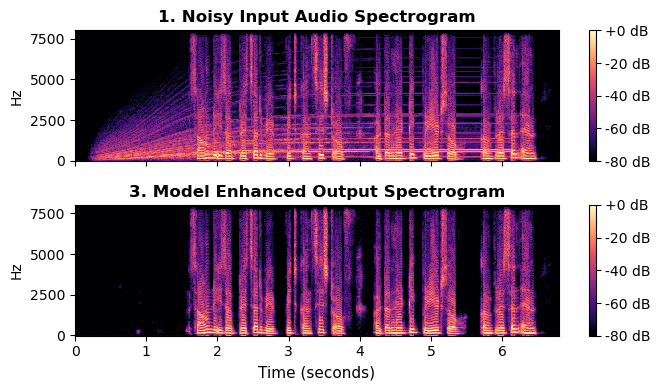

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def plot_spectrogram_comparison(noisy_path, enhanced_path, sample_rate=16000, n_fft=512, hop_length=128):
    
    # 1. Load Audio Files with Librosa
    y_noisy, _ = librosa.load(noisy_path, sr=sample_rate, mono=True)
    y_enhanced, _ = librosa.load(enhanced_path, sr=sample_rate, mono=True)

    # Align lengths for consistent visualization if durations differ slightly
    min_len = min(len(y_noisy), len(y_enhanced))
    y_noisy = y_noisy[:min_len]
    y_enhanced = y_enhanced[:min_len]

    # 2. Compute STFT & Convert Magnitude to dB Scale
    spec_noisy = librosa.stft(y_noisy, n_fft=n_fft, hop_length=hop_length)
    spec_enhanced = librosa.stft(y_enhanced, n_fft=n_fft, hop_length=hop_length)

    db_noisy = librosa.amplitude_to_db(np.abs(spec_noisy), ref=np.max)
    db_enhanced = librosa.amplitude_to_db(np.abs(spec_enhanced), ref=np.max)

    
    fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, sharey=True)

    # --- Plot 1: Noisy Input ---
    img1 = librosa.display.specshow(
        db_noisy, sr=sample_rate, hop_length=hop_length,
        x_axis='time', y_axis='hz', ax=axes[0], cmap='magma'
    )
    axes[0].set_title("1. Noisy Input Audio Spectrogram", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("")
    fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")


    # --- Plot 3: Model Enhanced Output ---
    img3 = librosa.display.specshow(
        db_enhanced, sr=sample_rate, hop_length=hop_length,
        x_axis='time', y_axis='hz', ax=axes[1], cmap='magma'
    )
    axes[1].set_title("3. Model Enhanced Output Spectrogram", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Time (seconds)", fontsize=11)
    fig.colorbar(img3, ax=axes[1], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()


#EXAMPLE

if __name__ == "__main__":
    # Provide your path variables here:
    NOISY_FILE = "ok.wav"
    ENHANCED_FILE = "output.wav"

    # Call Plotting Functionml/clear/THIS 20 SECOND ADVICE WILL CHANGE YOUR LIFE  motivation  inspiration  mindset - Motiversity (1).wav
    plot_spectrogram_comparison(NOISY_FILE, ENHANCED_FILE)

In [24]:
import numpy as np
import librosa
from pystoi import stoi

def calculate_vad_snr(audio, top_db=25):
    intervals = librosa.effects.split(audio, top_db=top_db)
    speech_mask = np.zeros_like(audio, dtype=bool)
    for start, end in intervals:
        speech_mask[start:end] = True

    speech_frames = audio[speech_mask]
    noise_frames = audio[~speech_mask]

    if len(speech_frames) == 0 or len(noise_frames) == 0:
        return 0.0

    p_speech = np.mean(speech_frames ** 2)
    p_noise = np.mean(noise_frames ** 2)
    return 10 * np.log10(p_speech / (p_noise + 1e-8))

# Load clean and enhanced audio
clean, sr = librosa.load(r"clear/p226_014_mic1i.wav", sr=16000)
enhanced, _ = librosa.load("output.wav", sr=16000)

min_len = min(len(clean), len(enhanced))
clean, enhanced = clean[:min_len], enhanced[:min_len]

# Compute STOI (Clarity) and VAD SNR
stoi_score = stoi(clean, enhanced, 16000, extended=False)
vad_snr = calculate_vad_snr(enhanced)

print(f"STOI Score (Clarity)     : {stoi_score:.3f} / 1.000")
print(f"Non-Ref VAD Estimated SNR: {vad_snr:.2f} dB")

STOI Score (Clarity)     : 0.085 / 1.000
Non-Ref VAD Estimated SNR: 28.86 dB
